In [ ]:
#eda on raw dataset
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


In [ ]:
df= pd.read_csv('/content/cleaned_dataset.csv')

In [ ]:
df.head()

,Service Unit,Bill Unit,Pay Unit,Bill Rate,Pay Rate,Payroll OTUnits,Payroll UnitsWithoutOT,Payroll OTAmount,Payroll RegAmount,Total Payroll Amount,Gender,Age,Marital Status,Race,IsCaregiverTerminated,CaregiverTenureYears,Caregiver Attributes_Can do Nights,Caregiver Attributes_Can do Days
0,Caregiver Training,Hourly,Hourly,35.0,0.0,0.0,3.93,0.0,0.0,0.0,Male,53,Married,Asian Canadian,0,11,0,1
1,Personal Care,Hourly,Hourly,36.0,22.5,0.0,4.00,0.0,90.0,90.0,Female,52,Unknown,British Canadian,1,6,1,1
2,Personal Care,Hourly,Hourly,34.0,22.0,0.0,6.00,0.0,132.0,132.0,Female,52,Unknown,British Canadian,1,6,1,1
3,Personal Care,Hourly,Hourly,41.0,18.0,0.0,12.00,0.0,216.0,216.0,Female,55,Single,Middle Eastern Canadian,1,5,0,1
4,RPNRN Shift,Hourly,Hourly,60.0,40.0,0.0,2.00,0.0,80.0,80.0,Female,60,Married,Middle Eastern Canadian,1,10,1,1


In [ ]:
null_counts = df.isnull().sum()
print(null_counts)

Service Unit                          0
Bill Unit                             0
Pay Unit                              0
Bill Rate                             0
Pay Rate                              0
Payroll OTUnits                       0
Payroll UnitsWithoutOT                0
Payroll OTAmount                      0
Payroll RegAmount                     0
Total Payroll Amount                  0
Gender                                0
Age                                   0
Marital Status                        0
Race                                  0
IsCaregiverTerminated                 0
CaregiverTenureYears                  0
Caregiver Attributes_Can do Nights    0
Caregiver Attributes_Can do Days      0
dtype: int64


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Service Unit                        1000 non-null   object 
 1   Bill Unit                           1000 non-null   object 
 2   Pay Unit                            1000 non-null   object 
 3   Bill Rate                           1000 non-null   float64
 4   Pay Rate                            1000 non-null   float64
 5   Payroll OTUnits                     1000 non-null   float64
 6   Payroll UnitsWithoutOT              1000 non-null   float64
 7   Payroll OTAmount                    1000 non-null   float64
 8   Payroll RegAmount                   1000 non-null   float64
 9   Total Payroll Amount                1000 non-null   float64
 10  Gender                              1000 non-null   object 
 11  Age                                 1000 non

##EDA on cleaned dataset after preprocessing


##Numerical Cols



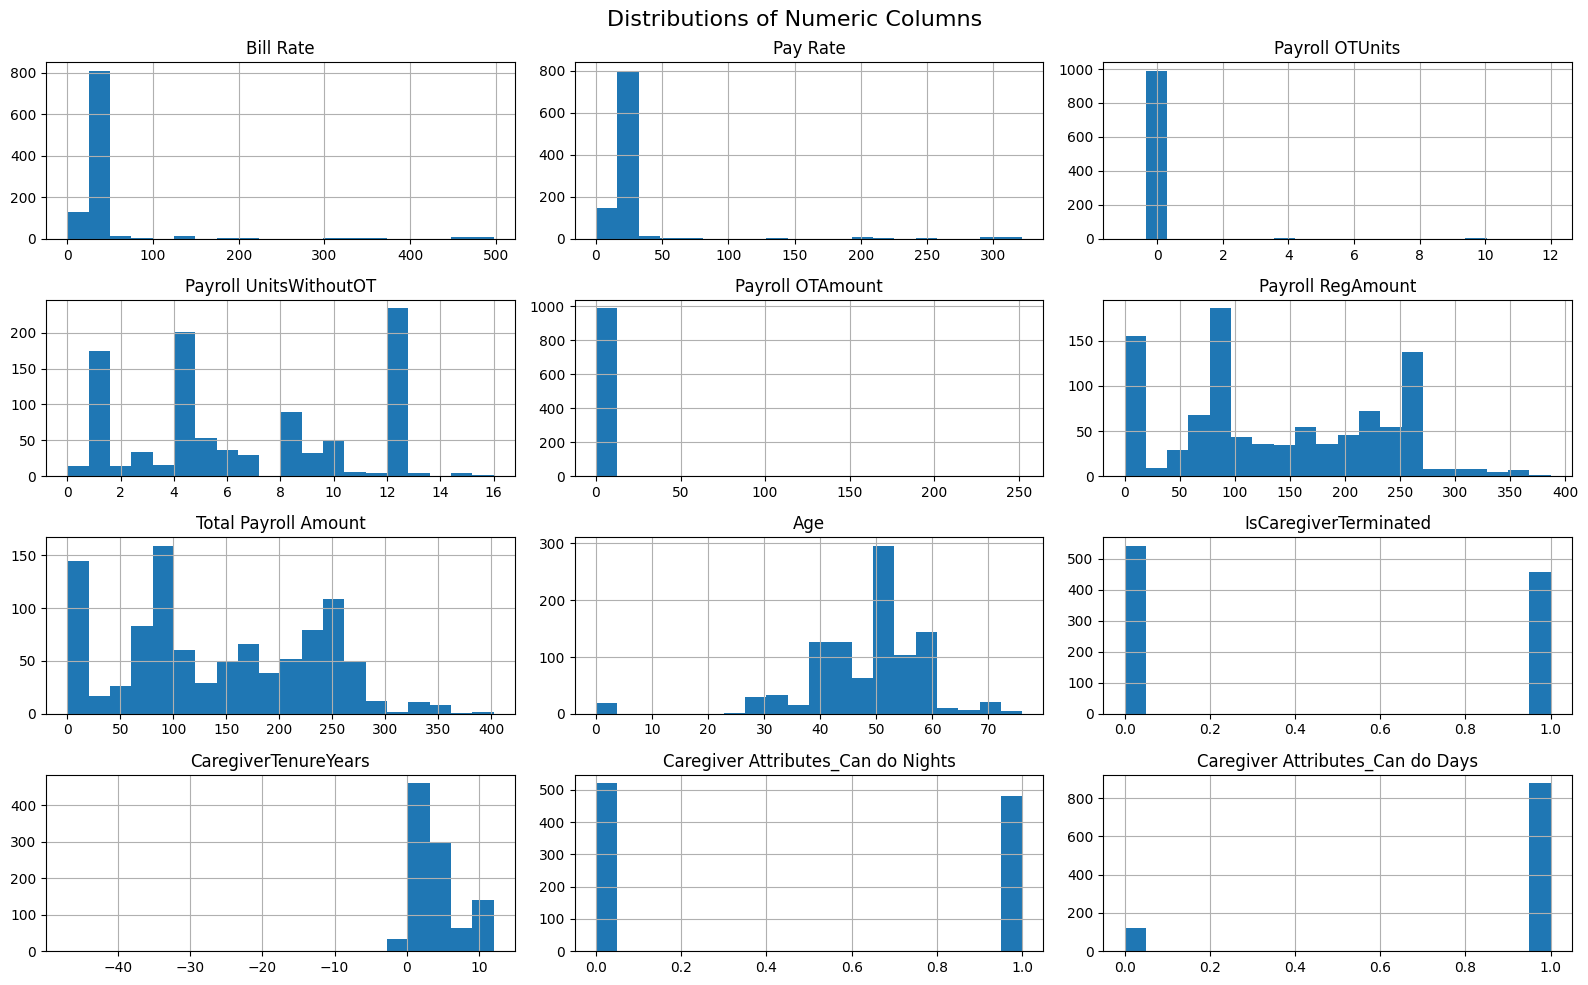

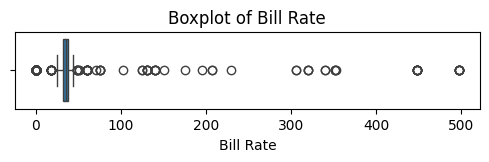

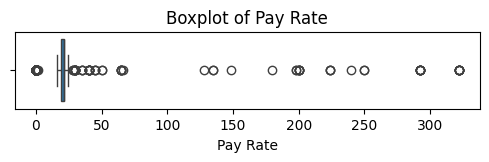

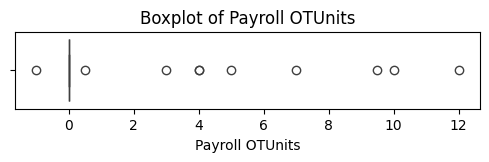

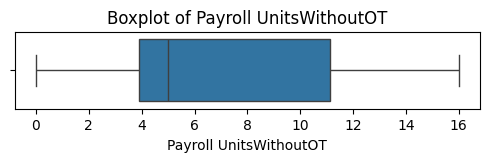

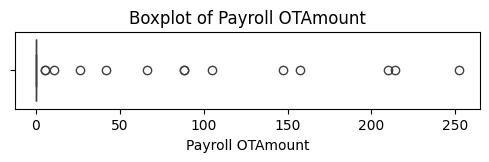

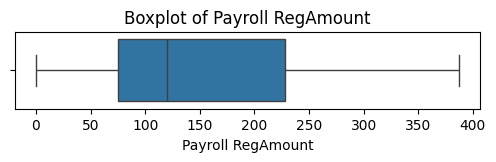

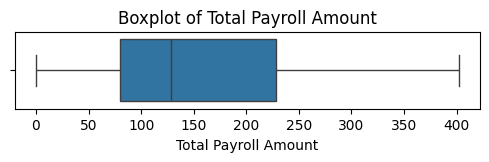

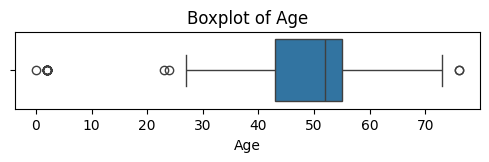

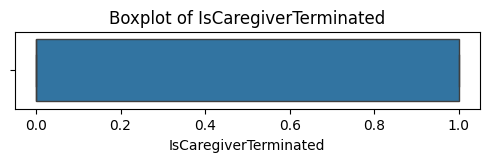

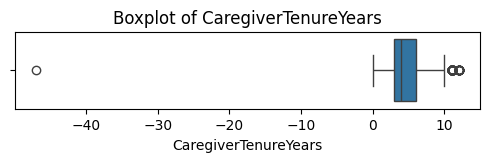

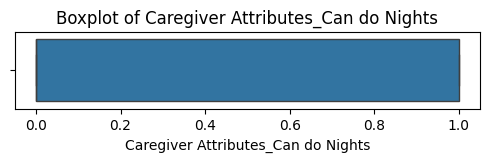

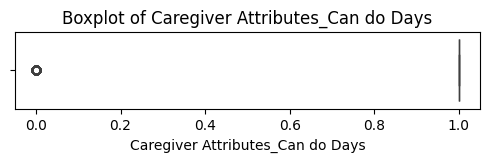

In [ ]:
numeric_cols = df.select_dtypes(include='number').columns

# Histograms
df[numeric_cols].hist(bins=20, figsize=(16, 10))
plt.suptitle("Distributions of Numeric Columns", fontsize=16)
plt.tight_layout()
plt.show()

# Boxplots to detect outliers
for col in numeric_cols:
    plt.figure(figsize=(6, 1))
    sns.boxplot(x=df[col])
    plt.title(f'Boxplot of {col}')
    plt.show()


##Categorical Cols


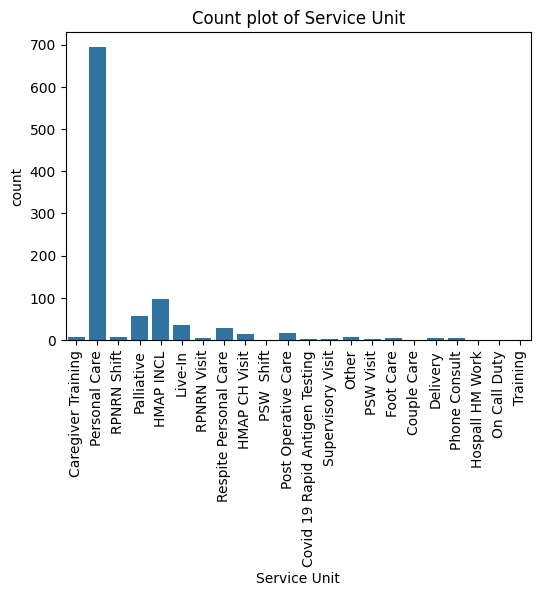

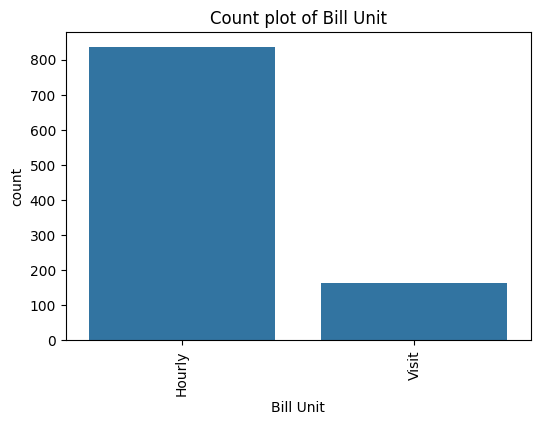

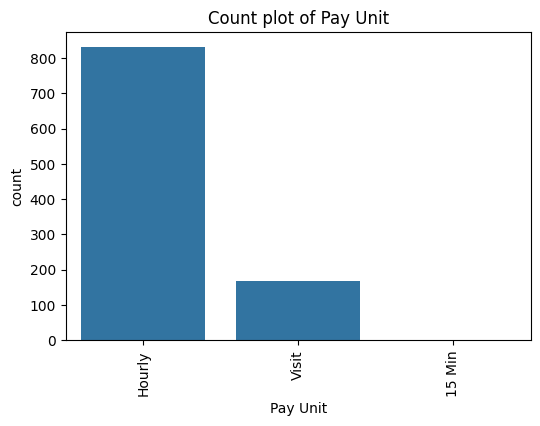

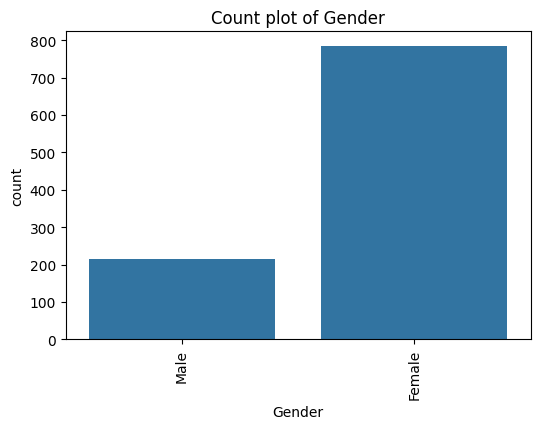

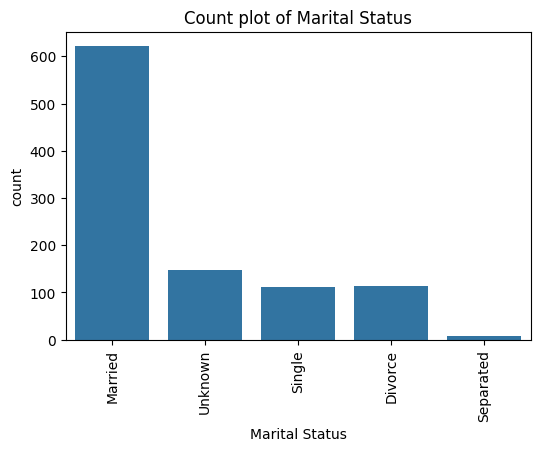

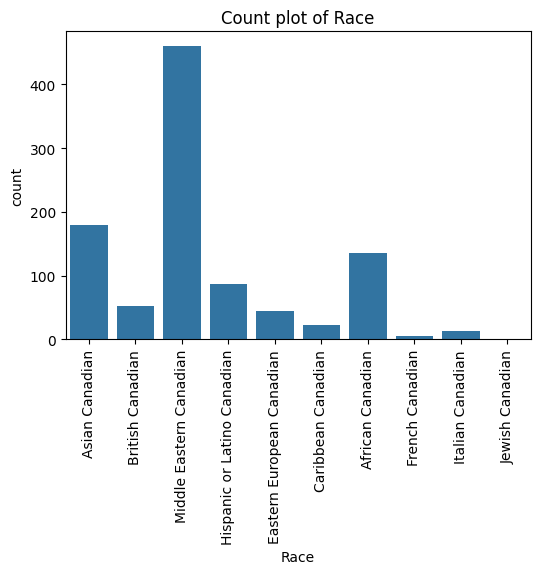

In [ ]:
categorical_cols = df.select_dtypes(exclude='number').columns

for col in categorical_cols:
    plt.figure(figsize=(6, 4))
    sns.countplot(data=df, x=col)
    plt.title(f'Count plot of {col}')
    plt.xticks(rotation=90)
    plt.show()


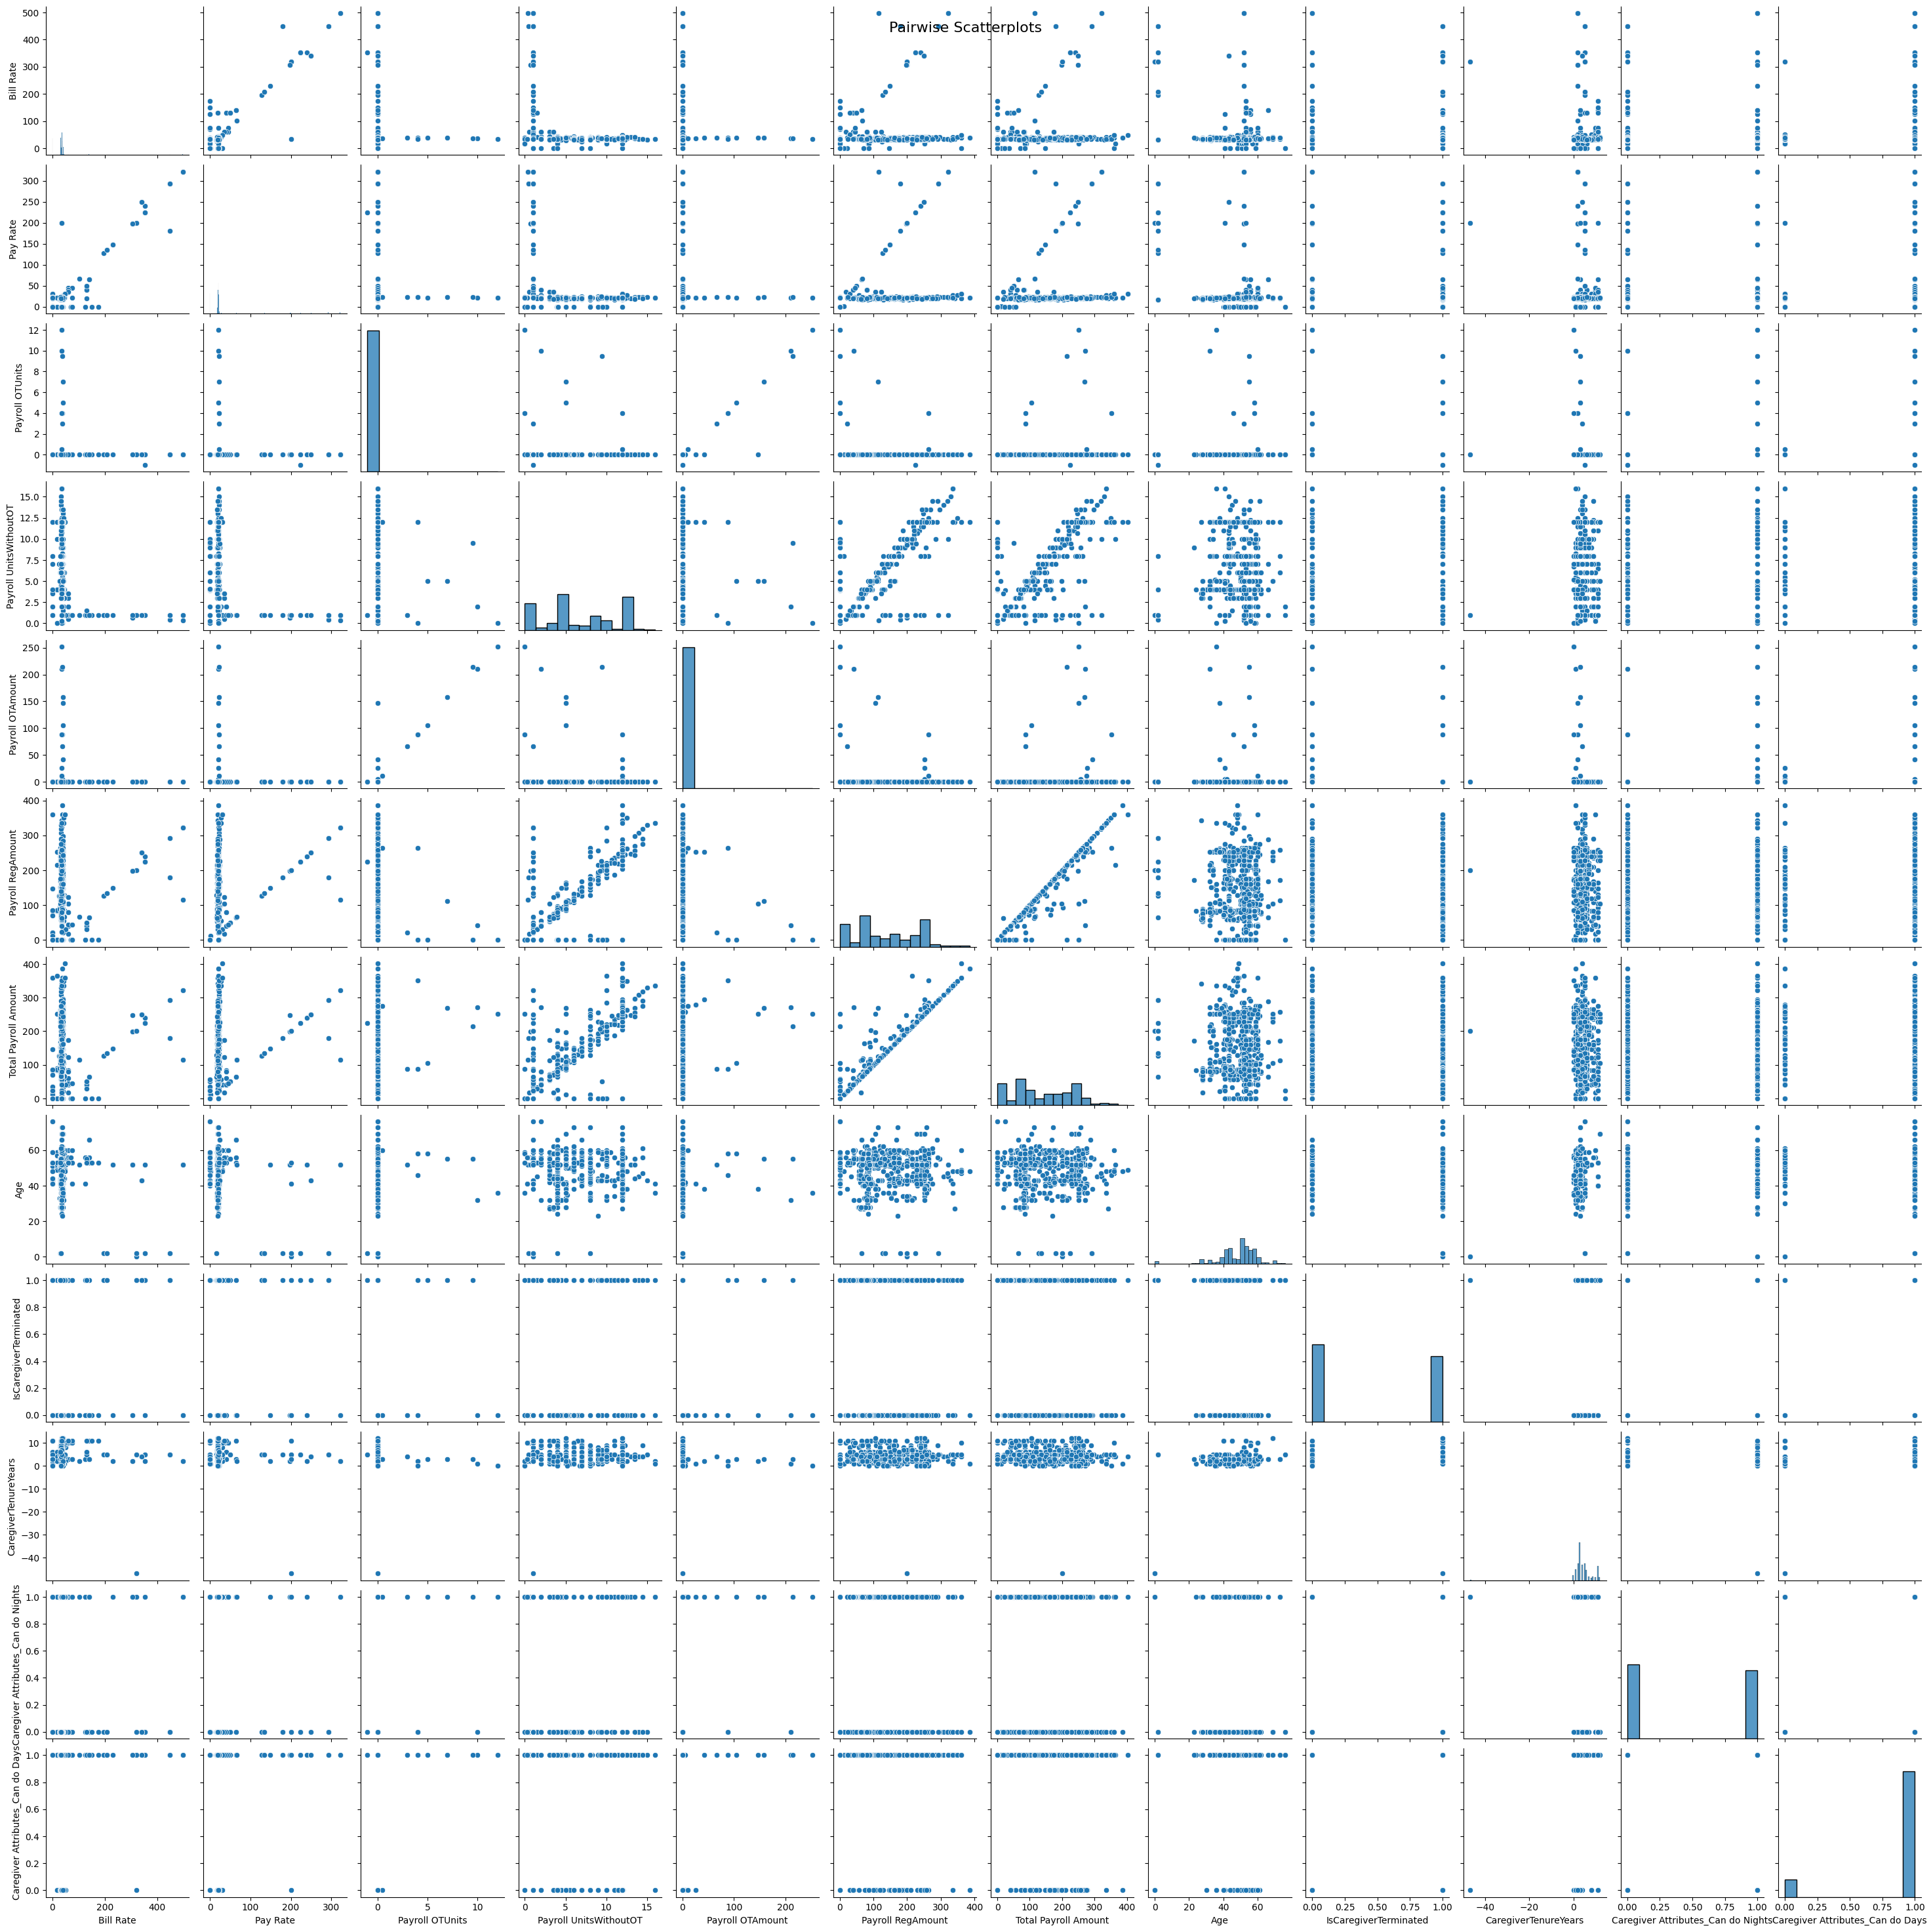

In [ ]:
# Correlation matrix will be covered later
sns.pairplot(df[numeric_cols])
plt.suptitle("Pairwise Scatterplots", fontsize=16)
plt.show()


##Correlation matrix between all the cols(numerical+categorical)

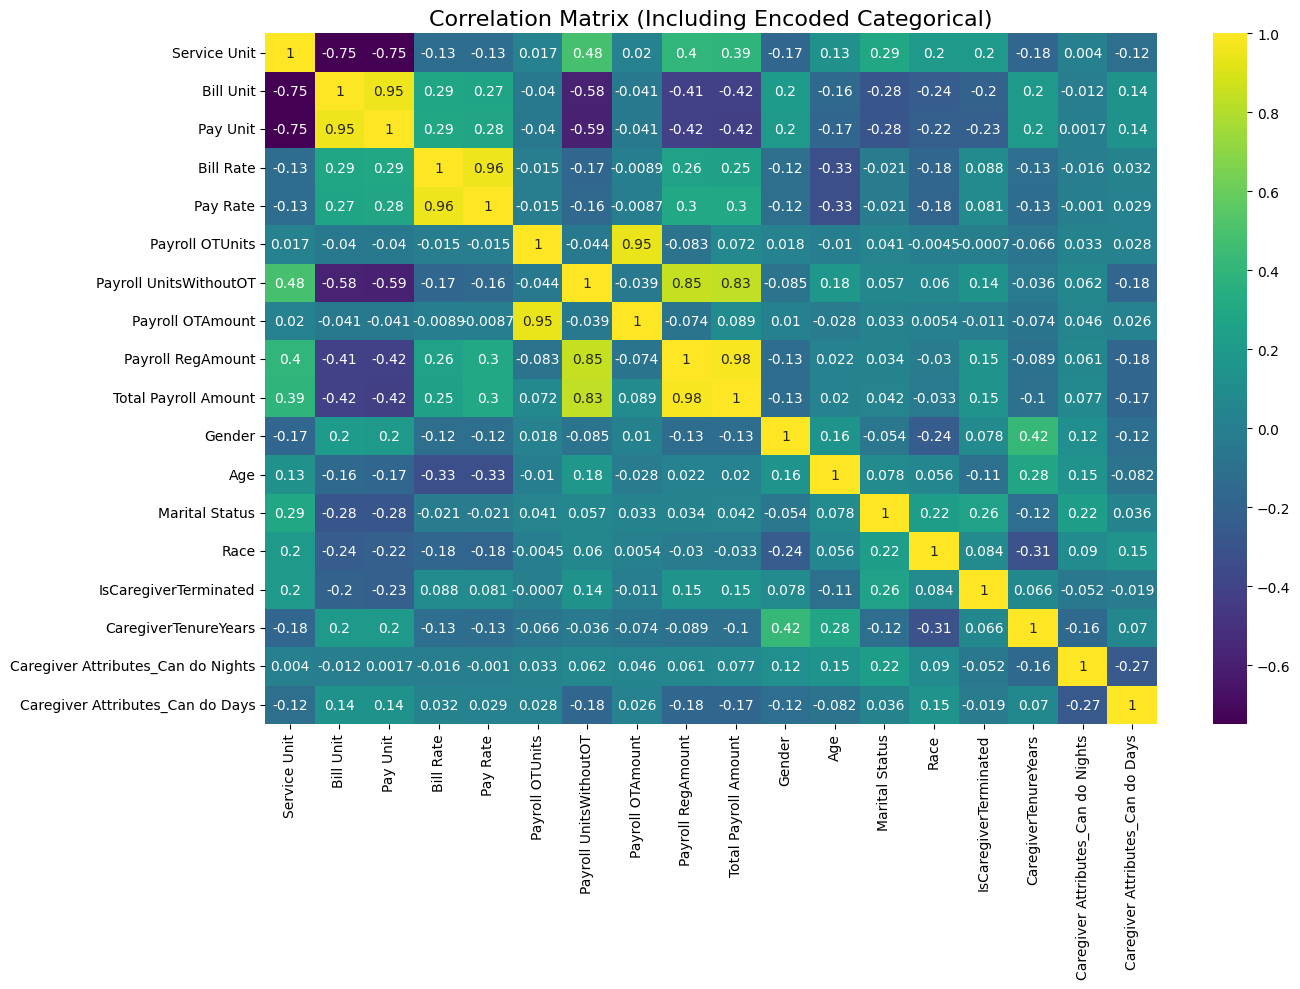

In [ ]:
from sklearn.preprocessing import LabelEncoder

df_encoded = df.copy()
for col in categorical_cols:
    le = LabelEncoder()
    df_encoded[col] = le.fit_transform(df[col])

# New correlation heatmap including categorical
plt.figure(figsize=(14, 10))
sns.heatmap(df_encoded.corr(), annot=True, cmap='viridis')
plt.title("Correlation Matrix (Including Encoded Categorical)", fontsize=16)
plt.tight_layout()
plt.show()


Bill Unit <-> Pay Unit\
Bill Rate <-> Pay Rate\
Payroll OTUnits <-> Payroll OTAmount\
PayrollRegAmount <-> TotalPayrollAmount

##Encode Categorical cols

In [ ]:
from sklearn.preprocessing import LabelEncoder

# Encode categorical features
categorical_cols = df.select_dtypes(include='object').columns

label_encoders = {}
for col in categorical_cols:
    le = LabelEncoder()
    df[col] = le.fit_transform(df[col])
    label_encoders[col] = le


#test train split


In [ ]:
target = 'IsCaregiverTerminated'

In [ ]:
from sklearn.model_selection import train_test_split

X = df.drop(columns=[target])
y = df[target]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)


##Using Random Forest to get 15 most imp features

In [ ]:
from sklearn.ensemble import RandomForestClassifier

rf = RandomForestClassifier(n_estimators=100, random_state=42)
rf.fit(X_train, y_train)

importances = rf.feature_importances_
features = X.columns

# Create DataFrame of feature importances
importances_df = pd.DataFrame({
    'Feature': features,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(importances_df)


                               Feature  Importance
11                                 Age    0.224933
14                CaregiverTenureYears    0.161624
12                      Marital Status    0.093537
9                 Total Payroll Amount    0.086810
8                    Payroll RegAmount    0.073626
3                            Bill Rate    0.069478
4                             Pay Rate    0.062148
13                                Race    0.062014
6               Payroll UnitsWithoutOT    0.043878
10                              Gender    0.032770
15  Caregiver Attributes_Can do Nights    0.029522
16    Caregiver Attributes_Can do Days    0.027129
0                         Service Unit    0.021234
1                            Bill Unit    0.004135
2                             Pay Unit    0.003504
7                     Payroll OTAmount    0.002617
5                      Payroll OTUnits    0.001041


<ipython-input-15-1666272495>:5: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=importances_df.head(15), x='Importance', y='Feature', palette='viridis')


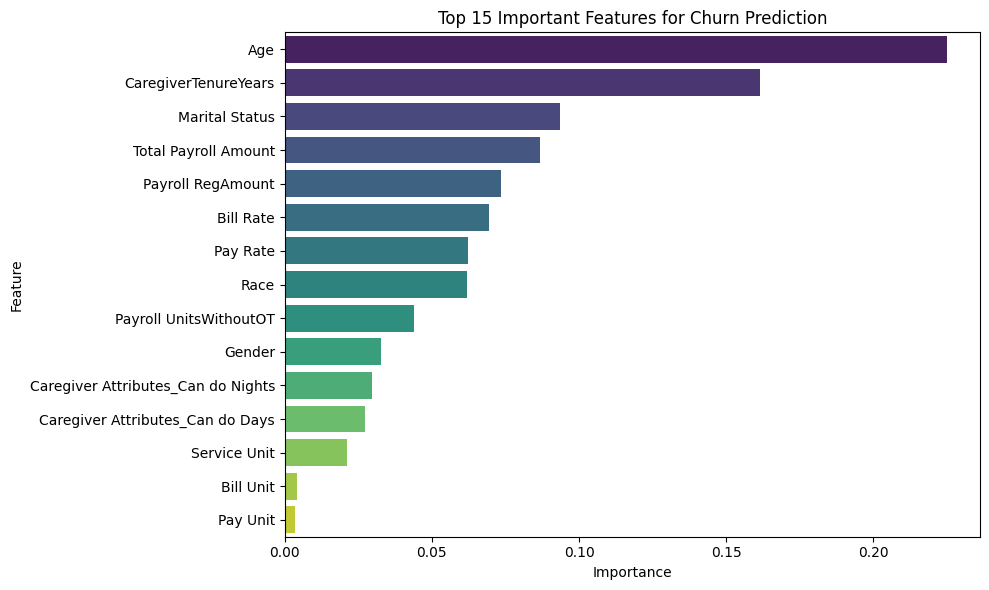

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.barplot(data=importances_df.head(15), x='Importance', y='Feature', palette='viridis')
plt.title("Top 15 Important Features for Churn Prediction")
plt.tight_layout()
plt.show()


### XGBoost Model

In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 18 columns):
 #   Column                              Non-Null Count  Dtype  
---  ------                              --------------  -----  
 0   Service Unit                        1000 non-null   int64  
 1   Bill Unit                           1000 non-null   int64  
 2   Pay Unit                            1000 non-null   int64  
 3   Bill Rate                           1000 non-null   float64
 4   Pay Rate                            1000 non-null   float64
 5   Payroll OTUnits                     1000 non-null   float64
 6   Payroll UnitsWithoutOT              1000 non-null   float64
 7   Payroll OTAmount                    1000 non-null   float64
 8   Payroll RegAmount                   1000 non-null   float64
 9   Total Payroll Amount                1000 non-null   float64
 10  Gender                              1000 non-null   int64  
 11  Age                                 1000 non

In [ ]:
import pandas as pd
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from xgboost import XGBClassifier


In [ ]:
# Assuming your DataFrame is named `df`
X = df.drop(columns=["IsCaregiverTerminated"])
y = df["IsCaregiverTerminated"]

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


In [ ]:
model = XGBClassifier(
    objective="binary:logistic",
    eval_metric="logloss",
    use_label_encoder=False,
    random_state=42
)

model.fit(X_train, y_train)


/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [12:59:13] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, gamma=None, grow_policy=None,
              importance_type=None, interaction_constraints=None,
              learning_rate=None, max_bin=None, max_cat_threshold=None,
              max_cat_to_onehot=None, max_delta_step=None, max_depth=None,
              max_leaves=None, min_child_weight=None, missing=nan,
              monotone_constraints=None, multi_strategy=None, n_estimators=None,
              n_jobs=None, num_parallel_tree=None, random_state=42, ...)

In [ ]:
y_pred = model.predict(X_test)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Confusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("Classification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.99
Confusion Matrix:
 [[107   1]
 [  1  91]]
Classification Report:
               precision    recall  f1-score   support

           0       0.99      0.99      0.99       108
           1       0.99      0.99      0.99        92

    accuracy                           0.99       200
   macro avg       0.99      0.99      0.99       200
weighted avg       0.99      0.99      0.99       200



<Figure size 1500x600 with 0 Axes>

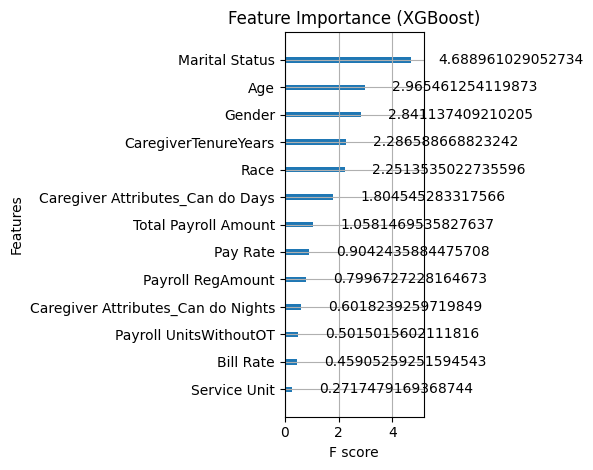

In [ ]:
import matplotlib.pyplot as plt
from xgboost import plot_importance

plt.figure(figsize=(15, 6))
plot_importance(model, importance_type="gain")
plt.title("Feature Importance (XGBoost)")
plt.tight_layout()
plt.show()


##Comparing 5 top models accuracies

In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import numpy as np

# Prepare model and data
X = df_encoded.drop("IsCaregiverTerminated", axis=1)
y = df_encoded["IsCaregiverTerminated"]


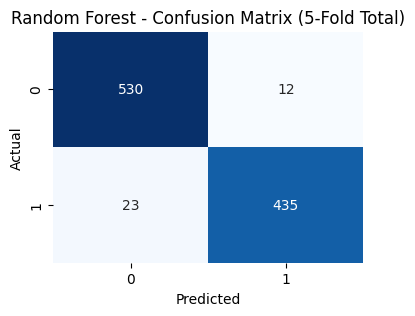


Classification Report for Random Forest:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       542
           1       0.97      0.95      0.96       458

    accuracy                           0.96      1000
   macro avg       0.97      0.96      0.96      1000
weighted avg       0.97      0.96      0.96      1000



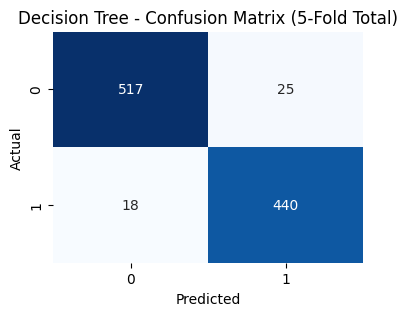


Classification Report for Decision Tree:

              precision    recall  f1-score   support

           0       0.97      0.95      0.96       542
           1       0.95      0.96      0.95       458

    accuracy                           0.96      1000
   macro avg       0.96      0.96      0.96      1000
weighted avg       0.96      0.96      0.96      1000



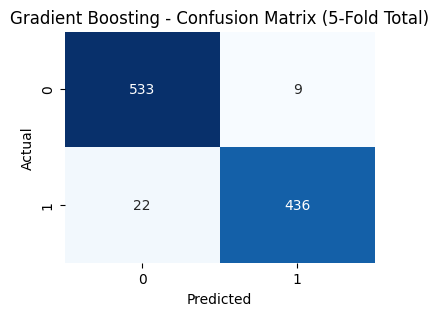


Classification Report for Gradient Boosting:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       542
           1       0.98      0.95      0.97       458

    accuracy                           0.97      1000
   macro avg       0.97      0.97      0.97      1000
weighted avg       0.97      0.97      0.97      1000



/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:00:06] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:00:07] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:00:08] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:00:09] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_encoder" } are not used.

  warnings.warn(smsg, UserWarning)
/usr/local/lib/python3.11/dist-packages/xgboost/core.py:158: UserWarning: [13:00:10] WARNING: /workspace/src/learner.cc:740: 
Parameters: { "use_label_e

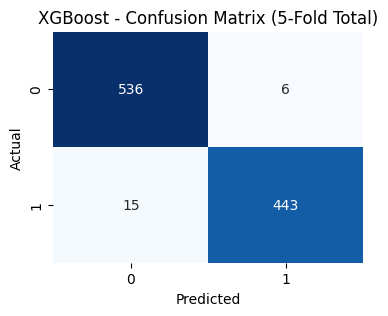


Classification Report for XGBoost:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       542
           1       0.99      0.97      0.98       458

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000

[LightGBM] [Warning] Found whitespace in feature_names, replace with underlines
[LightGBM] [Info] Number of positive: 367, number of negative: 433
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000338 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 331
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.458750 -> initscore=-0.165376
[LightGBM] [Info] Start training from score -0.165376
[Ligh

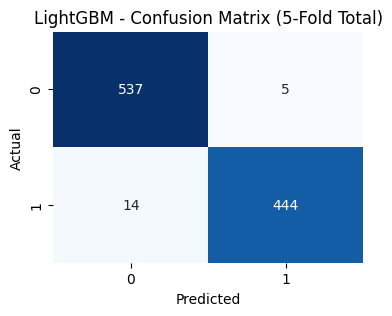


Classification Report for LightGBM:

              precision    recall  f1-score   support

           0       0.97      0.99      0.98       542
           1       0.99      0.97      0.98       458

    accuracy                           0.98      1000
   macro avg       0.98      0.98      0.98      1000
weighted avg       0.98      0.98      0.98      1000


Overall Comparison:
               Model  Accuracy  Precision    Recall  F1 Score
4           LightGBM     0.981   0.988788  0.969470  0.978981
3            XGBoost     0.979   0.986763  0.967320  0.976854
2  Gradient Boosting     0.969   0.980034  0.952007  0.965716
0      Random Forest     0.965   0.973701  0.949785  0.961365
1      Decision Tree     0.957   0.946171  0.960750  0.953310


In [ ]:
from sklearn.metrics import classification_report
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from lightgbm import LGBMClassifier
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Define models
models = {
    'Random Forest': RandomForestClassifier(random_state=42),
    'Decision Tree': DecisionTreeClassifier(random_state=42),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss'),
    'LightGBM': LGBMClassifier(random_state=42)
}

# Set up StratifiedKFold
skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)


def evaluate_model_with_cm_and_report(name, model):
    acc, prec, rec, f1 = [], [], [], []
    cm_total = np.array([[0, 0], [0, 0]])

    # Store all predictions and true labels for final report
    all_y_true = []
    all_y_pred = []

    for train_idx, test_idx in skf.split(X, y):
        X_train, X_val = X.iloc[train_idx], X.iloc[test_idx]
        y_train, y_val = y.iloc[train_idx], y.iloc[test_idx]

        model.fit(X_train, y_train)
        y_pred = model.predict(X_val)

        acc.append(accuracy_score(y_val, y_pred))
        prec.append(precision_score(y_val, y_pred))
        rec.append(recall_score(y_val, y_pred))
        f1.append(f1_score(y_val, y_pred))

        cm = confusion_matrix(y_val, y_pred)
        cm_total += cm

        all_y_true.extend(y_val)
        all_y_pred.extend(y_pred)

    # Confusion matrix plot
    plt.figure(figsize=(4, 3))
    sns.heatmap(cm_total, annot=True, fmt='d', cmap='Blues', cbar=False)
    plt.title(f'{name} - Confusion Matrix (5-Fold Total)')
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

    # Aggregated classification report
    print(f"\nClassification Report for {name}:\n")
    print(classification_report(all_y_true, all_y_pred, digits=2))

    return {
        'Model': name,
        'Accuracy': np.mean(acc),
        'Precision': np.mean(prec),
        'Recall': np.mean(rec),
        'F1 Score': np.mean(f1)
    }

# Run evaluations
results_cm = [evaluate_model_with_cm_and_report(name, model) for name, model in models.items()]

# Display metrics summary
results_cm_df = pd.DataFrame(results_cm)
print("\nOverall Comparison:")
print(results_cm_df.sort_values(by='F1 Score', ascending=False))


##Tuning and Cross validations


In [ ]:
models = {
    'GradientBoosting': {
        'model': GradientBoostingClassifier(),
        'params': {
            'model__n_estimators': [100],
            'model__learning_rate': [0.05],
            'model__max_depth': [3, 5],
            'model__min_samples_split': [5],
            'model__min_samples_leaf': [2],
            'model__subsample': [0.8]
        }
    },
    'DecisionTree': {
        'model': DecisionTreeClassifier(),
        'params': {
            'model__max_depth': [5, 10],
            'model__min_samples_split': [5],
            'model__min_samples_leaf': [2],
            'model__max_features': ['sqrt']
        }
    },
    'RandomForest': {
        'model': RandomForestClassifier(),
        'params': {
            'model__n_estimators': [100],
            'model__max_depth': [10],
            'model__min_samples_split': [5],
            'model__min_samples_leaf': [2],
            'model__bootstrap': [True]
        }
    },
    'LightGBM': {
        'model': LGBMClassifier(),
        'params': {
            'model__n_estimators': [100],
            'model__learning_rate': [0.05],
            'model__num_leaves': [20],
            'model__max_depth': [5],
            'model__min_child_samples': [20],
            'model__subsample': [0.8],
            'model__colsample_bytree': [0.8]
        }
    },
    'XGBoost': {
        'model': XGBClassifier(eval_metric='logloss', reg_alpha=0.5, reg_lambda=1),
        'params': {
            'model__n_estimators': [100],
            'model__max_depth': [5],
            'model__learning_rate': [0.05],
            'model__subsample': [0.8],
            'model__colsample_bytree': [0.8]
        }
    }
}


In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV

# Identify numeric and categorical columns
numeric_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()

# Preprocessing pipeline
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
    ]
)

def evaluate_model_with_tuning(name, model, params):
    pipe = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])

    grid = GridSearchCV(pipe, param_grid=params, cv=5, scoring='f1', n_jobs=-1)
    grid.fit(X, y)

    best_model = grid.best_estimator_
    y_pred = best_model.predict(X)

    print(f"\nBest parameters for {name}: {grid.best_params_}")
    print(f"Classification Report for {name}:\n")
    print(classification_report(y, y_pred))

    return {
        'Model': name,
        'Accuracy': accuracy_score(y, y_pred),
        'Precision': precision_score(y, y_pred),
        'Recall': recall_score(y, y_pred),
        'F1 Score': f1_score(y, y_pred)
    }


In [ ]:
results_cm = [evaluate_model_with_tuning(name, config['model'], config['params'])
              for name, config in models.items()]



Best parameters for GradientBoosting: {'model__learning_rate': 0.05, 'model__max_depth': 5, 'model__min_samples_leaf': 2, 'model__min_samples_split': 5, 'model__n_estimators': 100, 'model__subsample': 0.8}
Classification Report for GradientBoosting:

              precision    recall  f1-score   support

           0       0.99      1.00      1.00       542
           1       1.00      0.99      1.00       458

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000


Best parameters for DecisionTree: {'model__max_depth': 10, 'model__max_features': 'sqrt', 'model__min_samples_leaf': 2, 'model__min_samples_split': 5}
Classification Report for DecisionTree:

              precision    recall  f1-score   support

           0       0.96      0.98      0.97       542
           1       0.98      0.95      0.96       458

    accuracy                           0.97      1000
   macro a

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 458, number of negative: 542
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000209 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 373
[LightGBM] [Info] Number of data points in the train set: 1000, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.458000 -> initscore=-0.168397
[LightGBM] [Info] Start training from score -0.168397
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -in

In [ ]:
results_cm_df = pd.DataFrame(results_cm)
print("\nOverall Comparison:")
print(results_cm_df.sort_values(by='F1 Score', ascending=False))



Overall Comparison:
              Model  Accuracy  Precision    Recall  F1 Score
0  GradientBoosting     0.997   1.000000  0.993450  0.996714
2      RandomForest     0.994   0.995614  0.991266  0.993435
3          LightGBM     0.987   0.991170  0.980349  0.985730
4           XGBoost     0.987   0.995546  0.975983  0.985667
1      DecisionTree     0.967   0.977528  0.949782  0.963455


In [ ]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import OneHotEncoder

# Identify feature types
categorical_features = X.select_dtypes(include=['object', 'category']).columns.tolist()
numerical_features = X.select_dtypes(include=['int64', 'float64']).columns.tolist()

# Remove target leakage possibility manually (optional check)
# If any column is derived from the target or looks suspicious, drop it here

preprocessor = ColumnTransformer(transformers=[
    ('num', StandardScaler(), numerical_features),
    ('cat', OneHotEncoder(handle_unknown='ignore'), categorical_features)
])


##Best Hyperparameters for all 5 models

In [ ]:
from sklearn.model_selection import StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.metrics import classification_report, accuracy_score, precision_score, recall_score, f1_score, confusion_matrix

skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)

def evaluate_model_with_tuning(name, model, param_grid):
    pipeline = Pipeline([
        ('preprocessor', preprocessor),
        ('model', model)
    ])
    grid = GridSearchCV(pipeline, param_grid, cv=skf, n_jobs=-1, scoring='f1', error_score='raise')
    grid.fit(X_train, y_train)

    best_model = grid.best_estimator_
    y_test_pred = best_model.predict(X_test)

    print(f"\n{name} - Test Set Evaluation")
    print(classification_report(y_test, y_test_pred, digits=2))

    return {
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_test_pred),
        'Precision': precision_score(y_test, y_test_pred),
        'Recall': recall_score(y_test, y_test_pred),
        'F1 Score': f1_score(y_test, y_test_pred)
    }


In [ ]:
results_cm = [evaluate_model_with_tuning(name, config['model'], config['params']) for name, config in models.items()]
results_df = pd.DataFrame(results_cm)

print("\nOverall Model Comparison (on Hold-out Test Set):")
print(results_df.sort_values(by='F1 Score', ascending=False))



GradientBoosting - Test Set Evaluation
              precision    recall  f1-score   support

           0       0.98      0.99      0.99       121
           1       0.99      0.97      0.98        79

    accuracy                           0.98       200
   macro avg       0.99      0.98      0.98       200
weighted avg       0.99      0.98      0.98       200


DecisionTree - Test Set Evaluation
              precision    recall  f1-score   support

           0       0.88      0.95      0.91       121
           1       0.91      0.80      0.85        79

    accuracy                           0.89       200
   macro avg       0.90      0.87      0.88       200
weighted avg       0.89      0.89      0.89       200


RandomForest - Test Set Evaluation
              precision    recall  f1-score   support

           0       0.97      1.00      0.98       121
           1       1.00      0.95      0.97        79

    accuracy                           0.98       200
   macro avg    

/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(
/usr/local/lib/python3.11/dist-packages/sklearn/utils/deprecation.py:151: FutureWarning: 'force_all_finite' was renamed to 'ensure_all_finite' in 1.6 and will be removed in 1.8.
  warnings.warn(


[LightGBM] [Info] Number of positive: 379, number of negative: 421
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.000165 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 344
[LightGBM] [Info] Number of data points in the train set: 800, number of used features: 15
[LightGBM] [Info] [binary:BoostFromScore]: pavg=0.473750 -> initscore=-0.105097
[LightGBM] [Info] Start training from score -0.105097
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf
[LightGBM] [Warning] No further splits with positive gain, best gain: -inf

##Exploerd SHAP for Visual results

In [ ]:
!pip install shap


In [ ]:
# Identify non-numeric columns in X
non_numeric_cols = X.select_dtypes(include=['object']).columns
print("Non-numeric columns:", non_numeric_cols)



Non-numeric columns: Index([], dtype='object')


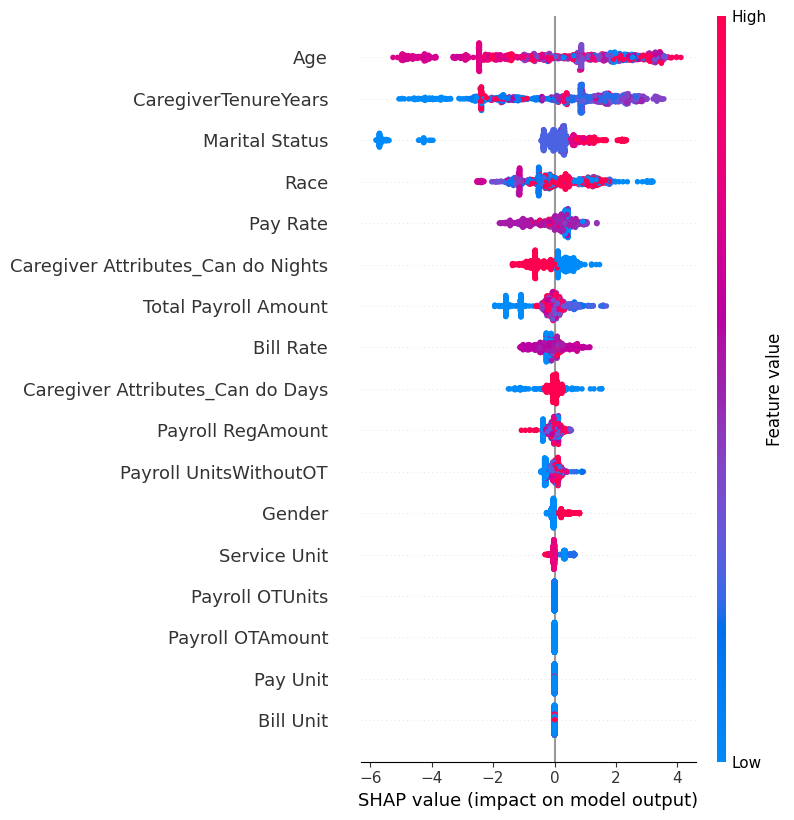

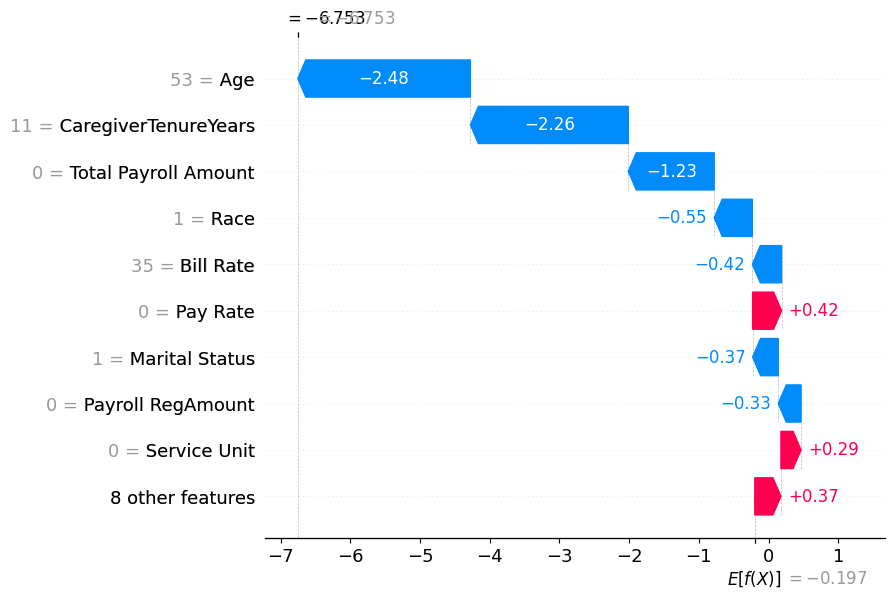

In [ ]:
import shap

# Use TreeExplainer for XGBoost models
explainer = shap.TreeExplainer(model)
shap_values = explainer.shap_values(X)

# Summary plot
shap.summary_plot(shap_values, X)

# Waterfall plot for first prediction
shap.plots.waterfall(shap.Explanation(values=shap_values[0], base_values=explainer.expected_value, data=X.iloc[0]))



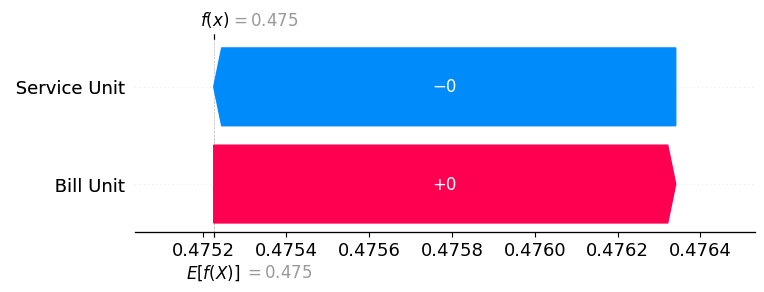

In [ ]:
import shap
import pandas as pd
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Step 1: Prepare Data
X = df_encoded.drop(columns=["IsCaregiverTerminated"])
y = df_encoded["IsCaregiverTerminated"]

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Step 2: Train Model
rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

# Step 3: Safe SHAP
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test)  # shap_values[1] → for class 1

# Step 4: SHAP Waterfall for First Sample
shap.plots._waterfall.waterfall_legacy(
    explainer.expected_value[1], shap_values[1][0], X_test.iloc[0]
)
